# Understanding the Count Plot

A count plot shows the **raw frequency (count) of each category** as a bar — it is the categorical equivalent of a histogram. Unlike a general bar chart (which can show any aggregation), a count plot always shows number of rows per category. It is the first step in univariate categorical EDA, immediately revealing class imbalance, dominant categories, and rare levels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

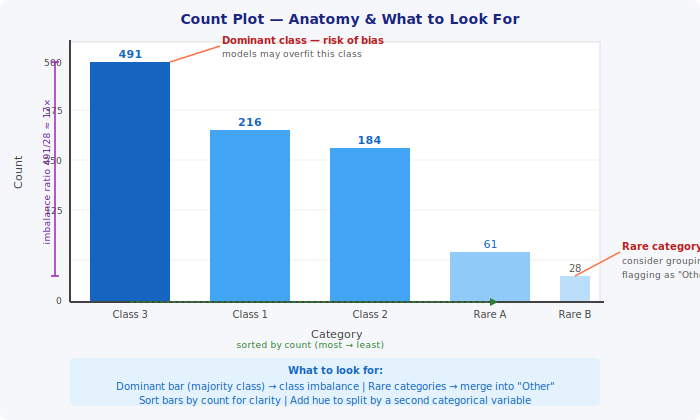

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="420"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="420" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Count Plot — Anatomy &amp; What to Look For</text>

  <!-- plot area -->
  <rect x="70" y="42" width="530" height="260" fill="white" stroke="#E0E0E0"/>

  <!-- gridlines -->
  <line x1="70" y1="110" x2="600" y2="110" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="70" y1="160" x2="600" y2="160" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="70" y1="210" x2="600" y2="210" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="70" y1="260" x2="600" y2="260" stroke="#F0F0F0" stroke-width="1"/>

  <!-- Bar 1: Class 3 — dominant -->
  <rect x="90"  y="62"  width="80" height="240" fill="#1565C0"/>
  <!-- Bar 2: Class 1 — moderate -->
  <rect x="210" y="130" width="80" height="172" fill="#42A5F5"/>
  <!-- Bar 3: Class 2 — moderate -->
  <rect x="330" y="148" width="80" height="154" fill="#42A5F5"/>
  <!-- Bar 4: Rare A -->
  <rect x="450" y="252" width="80" height="50"  fill="#90CAF9"/>
  <!-- Bar 5: Rare B -->
  <rect x="560" y="276" width="30" height="26"  fill="#BBDEFB"/>

  <!-- Count labels on bars -->
  <text x="130" y="58"  text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">491</text>
  <text x="250" y="126" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">216</text>
  <text x="370" y="144" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">184</text>
  <text x="490" y="248" text-anchor="middle" font-size="11" fill="#1565C0">61</text>
  <text x="575" y="272" text-anchor="middle" font-size="10" fill="#555">28</text>

  <!-- X-axis -->
  <line x1="70"  y1="302" x2="604" y2="302" stroke="#424242" stroke-width="2"/>
  <line x1="70"  y1="302" x2="70"  y2="40"  stroke="#424242" stroke-width="2"/>

  <!-- Y-axis labels -->
  <text x="62" y="66"  text-anchor="end" font-size="9" fill="#424242">500</text>
  <text x="62" y="114" text-anchor="end" font-size="9" fill="#424242">375</text>
  <text x="62" y="164" text-anchor="end" font-size="9" fill="#424242">250</text>
  <text x="62" y="214" text-anchor="end" font-size="9" fill="#424242">125</text>
  <text x="62" y="304" text-anchor="end" font-size="9" fill="#424242">0</text>
  <text x="22" y="172" text-anchor="middle" font-size="11" fill="#424242"
        transform="rotate(-90 22 172)">Count</text>

  <!-- X-axis category labels -->
  <text x="130" y="318" text-anchor="middle" font-size="10" fill="#424242">Class 3</text>
  <text x="250" y="318" text-anchor="middle" font-size="10" fill="#424242">Class 1</text>
  <text x="370" y="318" text-anchor="middle" font-size="10" fill="#424242">Class 2</text>
  <text x="490" y="318" text-anchor="middle" font-size="10" fill="#424242">Rare A</text>
  <text x="575" y="318" text-anchor="middle" font-size="10" fill="#424242">Rare B</text>
  <text x="337" y="338" text-anchor="middle" font-size="11" fill="#424242">Category</text>

  <!-- ANNOTATIONS -->
  <!-- Dominant bar -->
  <line x1="170" y1="62" x2="220" y2="46" stroke="#FF7043" stroke-width="1.5"/>
  <text x="222" y="44" font-size="10" font-weight="bold" fill="#B71C1C">Dominant class — risk of bias</text>
  <text x="222" y="57" font-size="9" fill="#555">models may overfit this class</text>

  <!-- Ordered by count annotation -->
  <line x1="130" y1="302" x2="490" y2="302" stroke="#2E7D32" stroke-width="1.5" stroke-dasharray="4,2"/>
  <polygon points="490,298 498,302 490,306" fill="#2E7D32"/>
  <text x="310" y="348" text-anchor="middle" font-size="9" fill="#2E7D32">sorted by count (most → least)</text>

  <!-- Rare category annotation -->
  <line x1="575" y1="276" x2="620" y2="252" stroke="#FF7043" stroke-width="1.5"/>
  <text x="622" y="250" font-size="10" font-weight="bold" fill="#B71C1C">Rare category</text>
  <text x="622" y="264" font-size="9" fill="#555">consider grouping or</text>
  <text x="622" y="278" font-size="9" fill="#555">flagging as "Other"</text>

  <!-- Imbalance ratio bracket -->
  <line x1="55" y1="62" x2="55" y2="276" stroke="#9C27B0" stroke-width="1.5"/>
  <line x1="51" y1="62"  x2="59" y2="62"  stroke="#9C27B0" stroke-width="1.5"/>
  <line x1="51" y1="276" x2="59" y2="276" stroke="#9C27B0" stroke-width="1.5"/>
  <text x="50" y="172" text-anchor="middle" font-size="9" fill="#6A1B9A"
        transform="rotate(-90 50 172)">imbalance ratio 491/28 ≈ 17×</text>

  <!-- Takeaway -->
  <rect x="70" y="358" width="530" height="48" fill="#E3F2FD" rx="4"/>
  <text x="335" y="374" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="335" y="390" text-anchor="middle" font-size="10" fill="#1565C0">Dominant bar (majority class) → class imbalance   |   Rare categories → merge into "Other"</text>
  <text x="335" y="404" text-anchor="middle" font-size="10" fill="#1565C0">Sort bars by count for clarity   |   Add hue to split by a second categorical variable</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Count Plot

| Feature | What it tells you |
|---|---|
| **Tallest bar** | Most frequent category — dominant class |
| **Shortest bar** | Rarest category — consider merging with similar levels |
| **Bars roughly equal** | Balanced dataset — ideal for classification |
| **One bar much taller** | Class imbalance — check model evaluation metrics (F1, AUC, not accuracy) |
| **Many tiny bars** | High cardinality — apply rare-level grouping before encoding |
| **Hue = target** | Shows which classes are associated with each category |

**Count plot vs bar chart:** A count plot always shows raw counts. A bar chart can show any metric (mean, sum, etc.). Use `sns.countplot()` for counts, `sns.barplot()` for means.

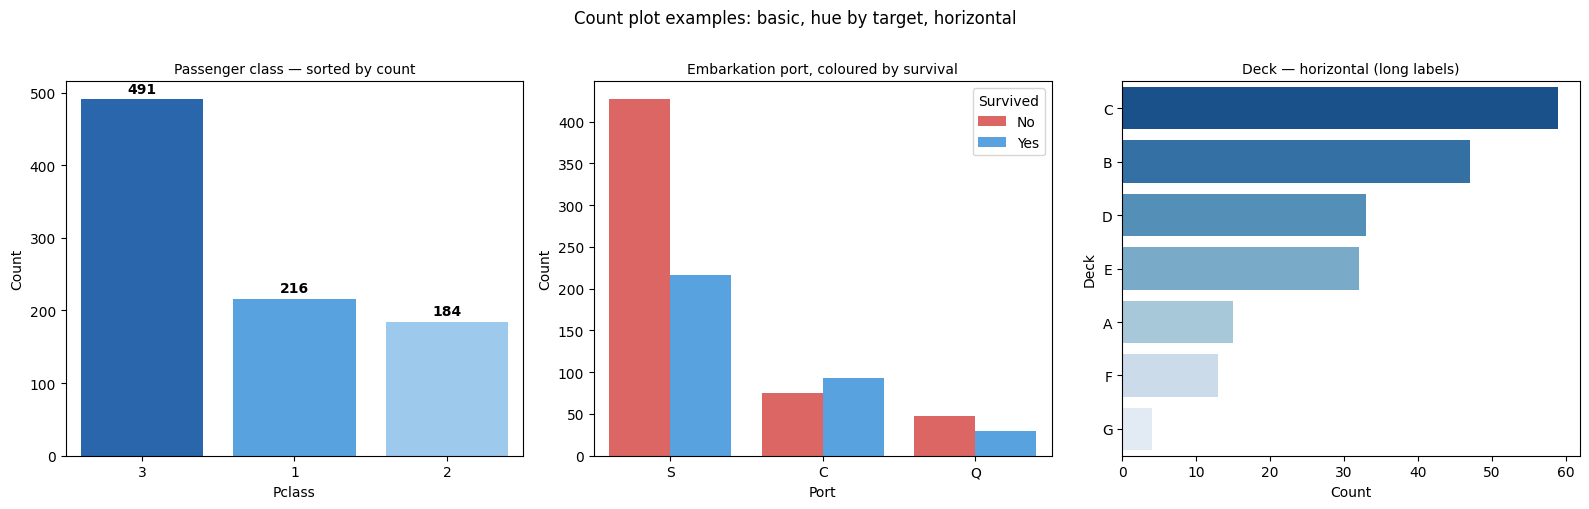

In [3]:
df = sns.load_dataset('titanic')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Basic count plot sorted by count
order_pclass = df['pclass'].value_counts().index
sns.countplot(data=df, x='pclass', order=order_pclass, ax=axes[0],
              palette=['#1565C0', '#42A5F5', '#90CAF9'])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, int(bar.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Passenger class — sorted by count', fontsize=10)
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Count')

# Count plot with hue (target variable)
order_embarked = df['embarked'].value_counts().dropna().index
sns.countplot(data=df.dropna(subset=['embarked']), x='embarked',
              hue='survived', order=order_embarked,
              palette={0: '#EF5350', 1: '#42A5F5'}, ax=axes[1])
axes[1].set_title('Embarkation port, coloured by survival', fontsize=10)
axes[1].set_xlabel('Port')
axes[1].set_ylabel('Count')
axes[1].legend(title='Survived', labels=['No', 'Yes'])

# Horizontal count plot for categories with long names
order_deck = df['deck'].value_counts().index
sns.countplot(data=df.dropna(subset=['deck']), y='deck',
              order=order_deck, ax=axes[2],
              palette=sns.color_palette('Blues_r', len(order_deck)))
axes[2].set_title('Deck — horizontal (long labels)', fontsize=10)
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Deck')

plt.suptitle('Count plot examples: basic, hue by target, horizontal', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Univariate categorical distribution — raw frequencies |
| **Class imbalance** | One bar dominates → use SMOTE / class weights / stratified splits |
| **Hue** | Add target variable as hue to see conditional distribution in one chart |
| **Sorting** | Always sort by count for readability |
| **Horizontal** | Use when category names are long |
| **vs Pie chart** | Count plot is superior for 4+ categories — easier to compare bar heights than slice angles |
| **vs Bar chart** | Count plot = counts only; bar chart = any aggregation (mean, sum, etc.) |